In [1]:
# import sys
# print(sys.executable)
# # %pip install --force-reinstall pmdarima


In [2]:
import pandas as pd
data = pd.read_csv('economics/DOGE-USD.csv')
data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
1756,2022-08-31,0.061534,0.063333,0.061058,0.061330,0.061330,309748693.0
1757,2022-09-01,0.061336,0.062479,0.060194,0.062372,0.062372,328765413.0
1758,2022-09-02,0.062372,0.062712,0.060947,0.061635,0.061635,273453013.0
1759,2022-09-03,NaN,NaN,NaN,NaN,NaN,NaN
1760,2022-09-04,0.062682,0.062744,0.062667,0.062696,0.062696,297513408.0


In [3]:
data.corr(numeric_only=True)
# calculate the linear correlation coefficients between columns
# numeric_only: only take numeric column
# output a matrix values from -1 to 1
#  1.0 means a perfect positive relationship (as one goes up, the other goes up).
#  -1.0 means a perfect negative relationship (as one goes up, the other goes down).
#  0.0 means no linear relationship.

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000


In [4]:
data.isnull().sum()

Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [5]:
data['Date'] = pd.to_datetime(data['Date'])
# convert string to pandas datetime objects, allowing time-based filtering, resampling and time-series plotting 
# data.set_index('Date', inplace=True) 
# set date as index 
# uncommon method <-inplace=True change existing object;  =False: returns a new copy
data=data.set_index('Date')
data.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-08-31,0.061534,0.063333,0.061058,0.061330,0.061330,309748693.0
2022-09-01,0.061336,0.062479,0.060194,0.062372,0.062372,328765413.0
2022-09-02,0.062372,0.062712,0.060947,0.061635,0.061635,273453013.0
2022-09-03,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-04,0.062682,0.062744,0.062667,0.062696,0.062696,297513408.0


In [6]:
data.shape

(1761, 6)

In [7]:
data=data.dropna()
data.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-08-30,0.063899,0.064408,0.060550,0.061525,0.061525,328934727.0
2022-08-31,0.061534,0.063333,0.061058,0.061330,0.061330,309748693.0
2022-09-01,0.061336,0.062479,0.060194,0.062372,0.062372,328765413.0
2022-09-02,0.062372,0.062712,0.060947,0.061635,0.061635,273453013.0
2022-09-04,0.062682,0.062744,0.062667,0.062696,0.062696,297513408.0


In [8]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


Text(0, 0.5, 'Volume')

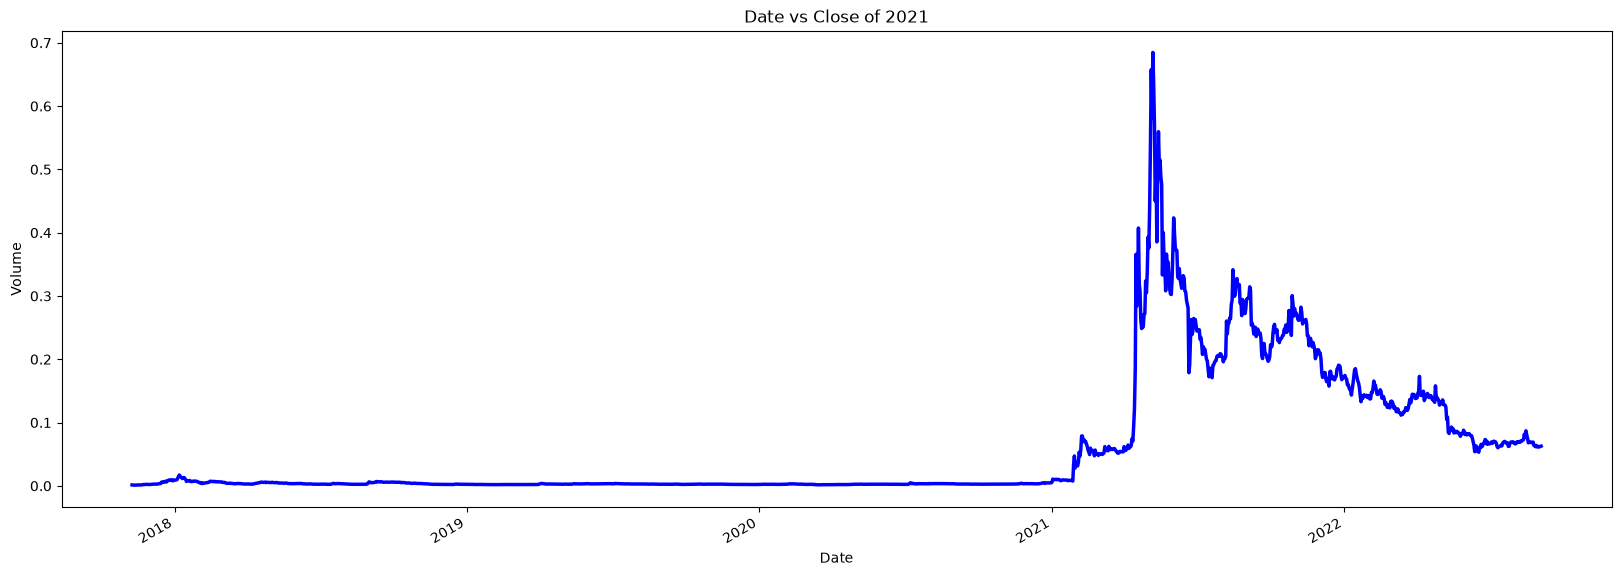

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,7))
x=data.groupby('Date')['Close'].mean()
x.plot(linewidth=2.5,color='b')
plt.title("Date vs Close of 2021")
plt.ylabel("Volume")

In [10]:
data['gap']=(data['High']-data['Low'])*data['Volume']
# highlights days where the price swung wildly and a massive amount of trading activity happened, signaling high market conviction or a major news event.
data['y']=data['High']/data['Volume']
# It acts as a normalized ratio, helping machine learning models understand whether high prices occurred during periods of high liquidity or low liquidity.
data['z']=data['Low']/data['Volume']
data['a']=data['High']/data['Low']
# A pure indicator of daily volatility percentage.
data['b']=(data['High']/data['Low'])*data['Volume']
# giving the model a single feature that captures both relative price volatility and market momentum.
abs(data.corr()['Close'].sort_values(ascending=False))

Close        1.000000
Adj Close    1.000000
High         0.995104
Low          0.994575
Open         0.992514
Volume       0.588678
b            0.456479
gap          0.383333
a            0.172057
z            0.063251
y            0.063868
Name: Close, dtype: float64

In [11]:
data=data[["Close","Volume","gap","a","b"]]
# drop highly correlated feature prevent from overfitting 
data.tail()

,Close,Volume,gap,a,b
Date,,,,,
2022-08-30,0.061525,328934727.0,1.269030e+06,1.063716,3.498931e+08
2022-08-31,0.061330,309748693.0,7.046783e+05,1.037260,3.212898e+08
2022-09-01,0.062372,328765413.0,7.512290e+05,1.037961,3.412455e+08
2022-09-02,0.061635,273453013.0,4.826446e+05,1.028960,2.813721e+08
2022-09-04,0.062696,297513408.0,2.290853e+04,1.001229,2.978790e+08


In [12]:
df2=data.tail(30)
train=df2[:11]
test=df2[-19:]
print(train.shape,test.shape)
train.head(11)

(11, 5) (19, 5)


,Close,Volume,gap,a,b
Date,,,,,
2022-08-05,0.069765,3.362167e+08,9.619161e+05,1.042539,3.505190e+08
2022-08-06,0.068674,2.779791e+08,6.707636e+05,1.035182,2.877590e+08
2022-08-07,0.068940,2.048625e+08,4.408641e+05,1.031765,2.113700e+08
2022-08-08,0.070055,3.991834e+08,1.251440e+06,1.045486,4.173405e+08
2022-08-09,0.069125,6.113271e+08,3.315838e+06,1.079226,6.597604e+08
2022-08-10,0.071195,4.311727e+08,1.690197e+06,1.058170,4.562539e+08
2022-08-11,0.070930,5.639086e+08,2.209958e+06,1.055410,5.951549e+08
2022-08-12,0.072345,3.204104e+08,7.859666e+05,1.035029,3.316341e+08
2022-08-13,0.072840,4.462874e+08,1.298250e+06,1.040430,4.643310e+08


In [13]:
from pmdarima import auto_arima

# auto_arima searches for the best p, d, q combination
stepwise_fit = auto_arima(train['Close'], 
                          exogenous=train.drop('Close', axis=1), 
                          suppress_warnings=True)
print(stepwise_fit.order)
stepwise_fit

(1, 0, 0)


,order,"(1, ...)"
,suppress_warnings,True
,scoring_args,{}
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,out_of_sample_size,0
,scoring,'mse'
,trend,None
,with_intercept,True


In [14]:
# SARIMAX: seasonal autoregressive integrated moving average with exogenous regressor model 
# for time series analysis with (p,d,q)
# predict future value in time series based on past values and external factors
# p:autoregressive(AR): look back 2 time steps into the past to predict the next value. It assumes current price is heavily influenced by prices of last two days
# d:integration(I):differencing 1 time. subtract previous value from current value to make data stationary, which removes trends and stabilizes the mean.
# q:moving average(MA): looks back 1 time step at the past forecast errors to smooth out sudden shocks or noise
from statsmodels.tsa.statespace.sarimax import SARIMAX
model=SARIMAX(endog=train['Close'],exog=train.drop('Close',axis=1),order=(1,0,0))
# tutorial uses general order (2,1,1). After auto_arima we get the best order for this model. since it is small dataframe, subtract will lose information and there is no error from 11 datas
# the lower the AIC(Akaike Information Criterion, a statistical measure of model quality) value, the better the model 
# endogenous variable: target variable 
# exogenous variables: external features 
results=model.fit()
print(results.summary())
# coef (Coefficient): The weight or impact of that variable. For example, ar.L1 of 0.3318 means yesterday's value has a positive pull on today's value.
# P>|z| (P-value): Tells you if the feature is statistically significant. You want this value to be close to 0.000. If it's high (like 0.5 or 0.8), the feature isn't helping much. In your black-background table, almost all features have a p-value of 0.001 or 0.000, meaning they are highly significant!

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                   11
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  58.639
Date:                Tue, 06 Oct 2026   AIC                           -105.278
Time:                        13:58:41   BIC                           -102.890
Sample:                    08-05-2022   HQIC                          -106.783
                         - 08-15-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Volume      1.181e-09    3.6e-10      3.282      0.001    4.76e-10    1.89e-09
gap         1.649e-08   5.18e-09      3.184      0.001    6.34e-09    2.66e-08
a              0.0685   4.26e-10   1.61e+08      0.0

/Users/xiaoying/Desktop/machinelearning/machinelearning/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/xiaoying/Desktop/machinelearning/machinelearning/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/xiaoying/Desktop/machinelearning/machinelearning/venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [15]:
start=11
end=29
predictions = results.predict(
    start=start,
    end=end,
    exog=test.drop('Close',axis=1)
)
predictions

2022-08-16    0.100777
2022-08-17    0.087985
2022-08-18    0.077354
2022-08-19    0.067523
2022-08-20    0.069407
2022-08-21    0.069702
2022-08-22    0.069296
2022-08-23    0.069359
2022-08-24    0.069442
2022-08-25    0.070026
2022-08-26    0.066012
2022-08-27    0.068300
2022-08-28    0.068949
2022-08-29    0.068745
2022-08-30    0.068602
2022-08-31    0.068645
2022-09-01    0.068328
2022-09-02    0.068743
2022-09-03    0.068168
Freq: D, Name: predicted_mean, dtype: float64

<Axes: xlabel='Date'>

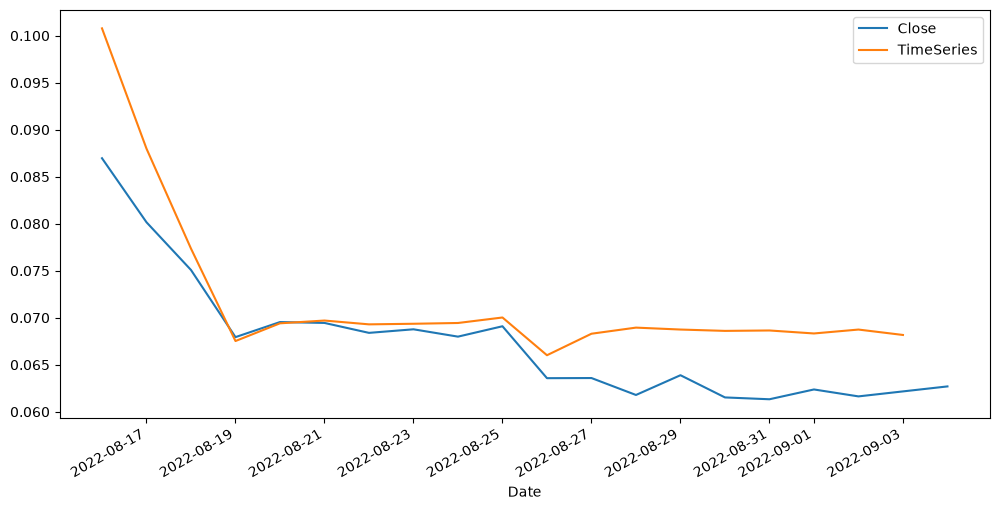

In [16]:
test['Close'].plot(legend=True,figsize=(12,6))
predictions.plot(label='TimeSeries',legend=True)